# Model vs. competitors — ranking & decision quality

TAUSO vs OligoAI / PFRED / OligoWalk / sfold / miRanda on the **held-out test split**, the
per-experiment cohort being a single patent inhibition table (`custom_id`).

**Remake:** `python -m notebooks.models.train_model` → `python -m notebooks.models.Evaluation.evaluate` → restart-run-all. Shared helpers live in `_viz.py`.

In [1]:
import _viz as v
v.setup_style()
import numpy as np, pandas as pd, matplotlib.pyplot as plt
R = v.load_results()
summary, preds = R['summary'], v.add_cohort_mean(R['preds'])
breakdown = R['breakdown']
print('test oligos:', len(preds), '| patent cohorts:', preds.custom_id.nunique(), '| scorers:', summary.scorer.nunique())

test oligos: 20846 | patent cohorts: 269 | scorers: 11


## 1 · Within-cohort ranking
Median per-cohort Spearman — the ASO-selection task (rank oligos *within* one experiment).

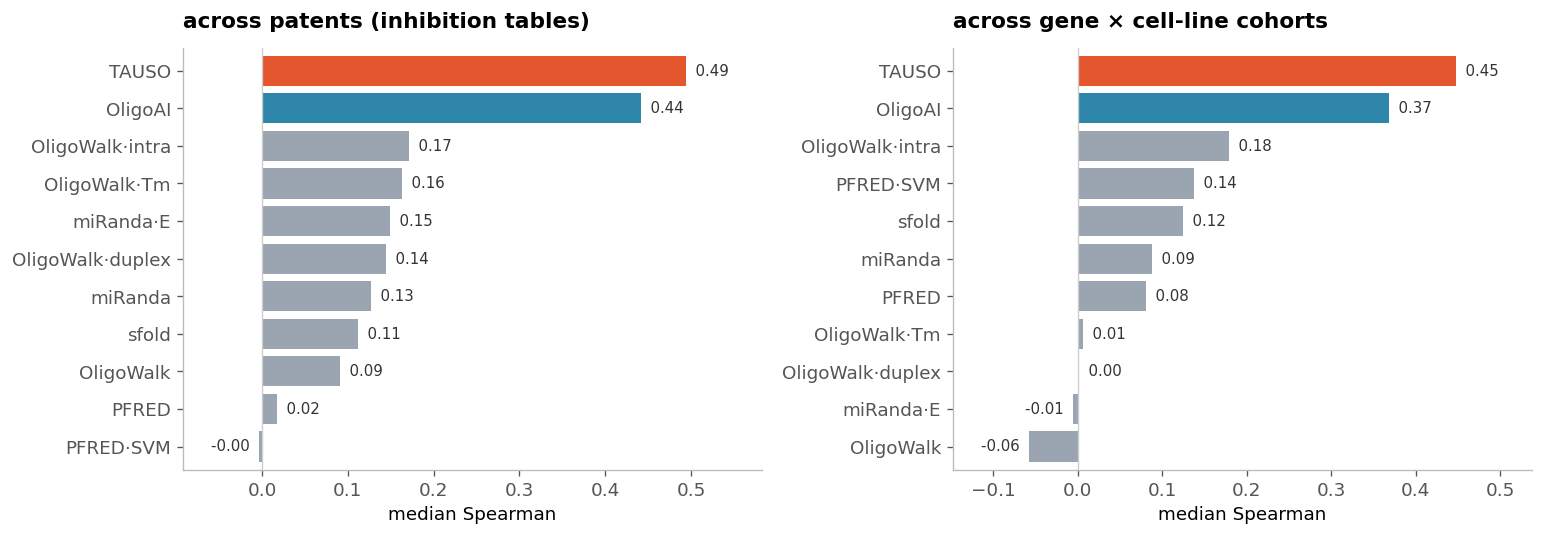

In [2]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))
for a, (g, ttl) in zip(ax, [('patent','across patents (inhibition tables)'), ('gene x cell_line','across gene × cell-line cohorts')]):
    d = summary[summary.grouping==g]
    o = v.order(d, 'spearman_median')
    v.hbar(a, o, d.set_index('scorer').reindex(o)['spearman_median'].values, title=ttl, xlabel='median Spearman')
plt.tight_layout(); plt.show()

/tmp/claude-1000/ipykernel_1861659/246567651.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([g[g.scorer==s].spearman.values for s in o], vert=False, patch_artist=True,


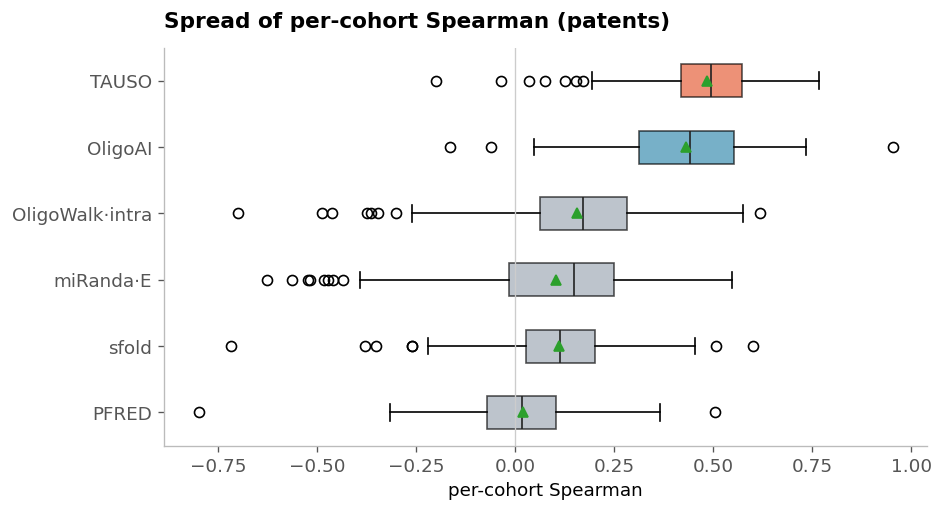

In [3]:
# spread of per-cohort Spearman (patent), headline scorers
pg = R['per_group']; g = pg[pg.grouping=='patent']
o = [s for s in v.order(summary[summary.grouping=='patent'],'spearman_median', v.HEADLINE) if s in set(g.scorer)]
fig, ax = plt.subplots(figsize=(8, 4.4))
bp = ax.boxplot([g[g.scorer==s].spearman.values for s in o], vert=False, patch_artist=True,
                labels=[v.disp(s) for s in o], showmeans=True, medianprops=dict(color='#222'))
for p, s in zip(bp['boxes'], o): p.set_facecolor(v.color(s)); p.set_alpha(.65)
ax.invert_yaxis(); ax.axvline(0, color='#ccc', lw=.8); ax.set_xlabel('per-cohort Spearman')
ax.set_title('Spread of per-cohort Spearman (patents)'); plt.tight_layout(); plt.show()

## 2 · Not just cohort means (anti-leakage)
A predictor that only knows each cohort's mean inhibition scores well **globally** but has
**zero** within-cohort ranking signal. TAUSO matches it globally *and* ranks within cohorts.

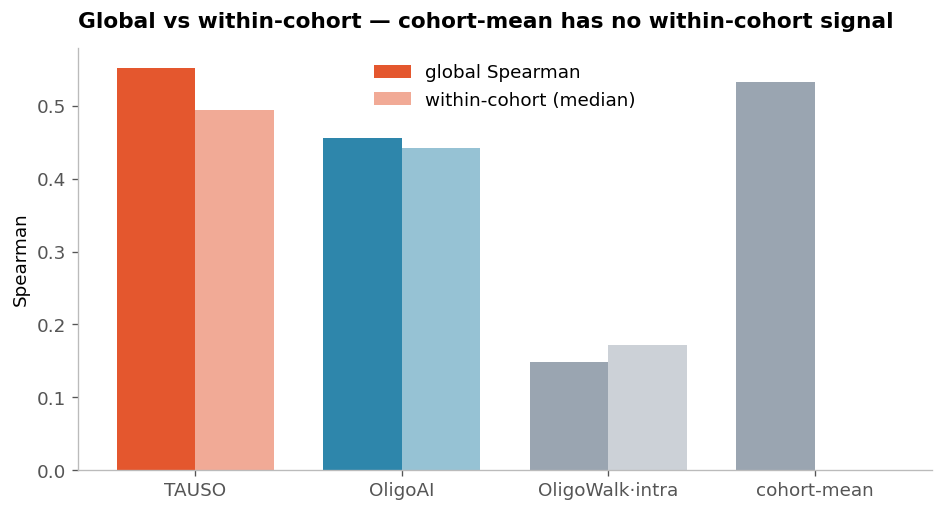

In [4]:
meth = ['TAUSO','oligo_ai_score','OW_Intra_Oligo','cohort_mean']
within = summary[summary.grouping=='patent'].set_index('scorer')['spearman_median']
glob = {m: v.global_spearman(preds, m) for m in meth}
wth = {m: (within.get(m, 0.0) if m!='cohort_mean' else 0.0) for m in meth}
x = np.arange(len(meth)); w = .38
fig, ax = plt.subplots(figsize=(8, 4.4))
ax.bar(x-w/2, [glob[m] for m in meth], w, label='global Spearman', color=[v.color(m) for m in meth])
ax.bar(x+w/2, [wth[m] for m in meth], w, label='within-cohort (median)', color=[v.color(m) for m in meth], alpha=.5)
ax.set_xticks(x); ax.set_xticklabels([v.disp(m) for m in meth]); ax.set_ylabel('Spearman')
ax.set_title('Global vs within-cohort — cohort-mean has no within-cohort signal'); ax.legend(frameon=False)
plt.tight_layout(); plt.show()

## 3 · Decision quality — picking candidates
What a chemist gets when synthesising the model's top picks.

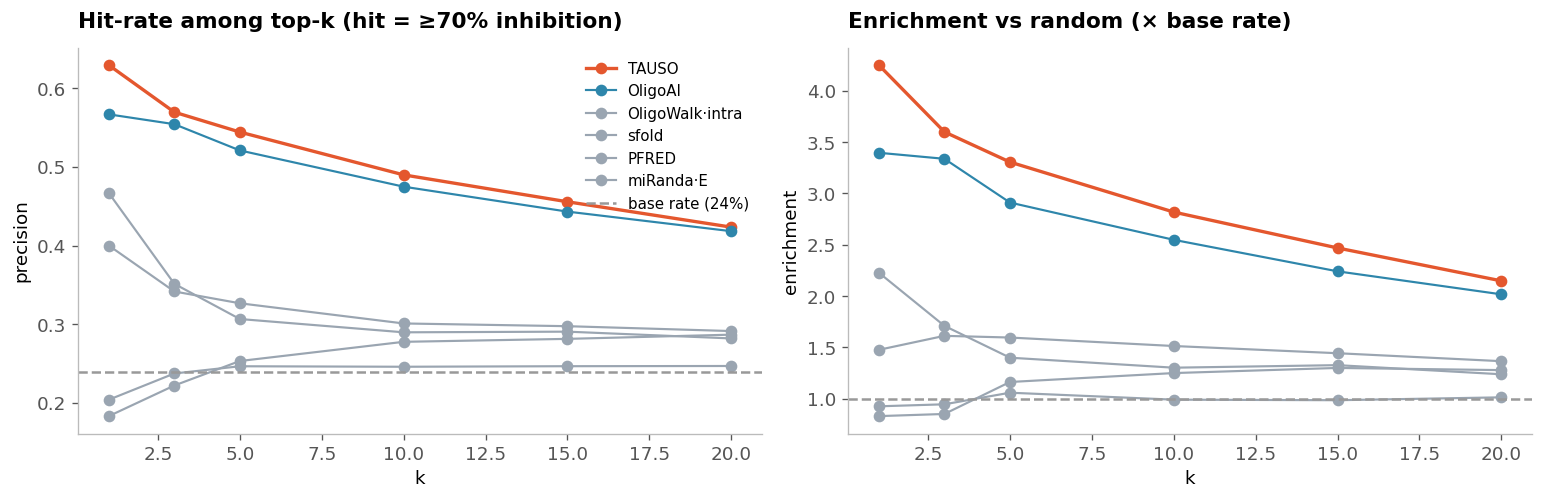

In [5]:
# enrichment / hit-rate: fraction of top-k picks that are strong knockdowns (>=70%)
thr = 70; ks = (1,3,5,10,15,20); base = v.base_hit_rate(preds, thr)
fig, ax = plt.subplots(1, 2, figsize=(13, 4.3))
for s in v.HEADLINE:
    c = v.hit_rate_curve(preds, s, thr, ks)
    ax[0].plot(c.k, c.precision, marker='o', color=v.color(s), label=v.disp(s), lw=2 if s=='TAUSO' else 1.3)
    ax[1].plot(c.k, c.enrichment, marker='o', color=v.color(s), lw=2 if s=='TAUSO' else 1.3)
ax[0].axhline(base, ls='--', color='#999', label=f'base rate ({base:.0%})')
ax[0].set_title(f'Hit-rate among top-k (hit = ≥{thr}% inhibition)'); ax[0].set_xlabel('k'); ax[0].set_ylabel('precision'); ax[0].legend(frameon=False, fontsize=9)
ax[1].axhline(1, ls='--', color='#999'); ax[1].set_title('Enrichment vs random (× base rate)'); ax[1].set_xlabel('k'); ax[1].set_ylabel('enrichment')
plt.tight_layout(); plt.show()

/tmp/claude-1000/ipykernel_1861659/1176832412.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, vert=False, patch_artist=True, labels=[v.disp(s) for s in o], showmeans=True, medianprops=dict(color='#222'))


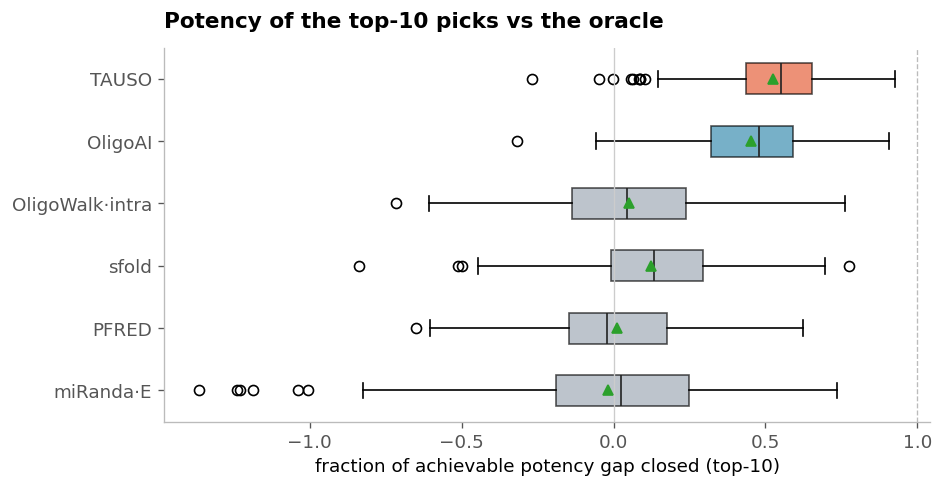

In [6]:
# potency gap closed by the top-10 picks: 0 = random, 1 = oracle
o = [s for s in v.HEADLINE]
data = [v.gap_closed(preds, s, k=10) for s in o]
fig, ax = plt.subplots(figsize=(8, 4.2))
bp = ax.boxplot(data, vert=False, patch_artist=True, labels=[v.disp(s) for s in o], showmeans=True, medianprops=dict(color='#222'))
for p, s in zip(bp['boxes'], o): p.set_facecolor(v.color(s)); p.set_alpha(.65)
ax.invert_yaxis(); ax.axvline(0, color='#ccc', lw=.8); ax.axvline(1, color='#bbb', lw=.8, ls='--')
ax.set_xlabel('fraction of achievable potency gap closed (top-10)'); ax.set_title('Potency of the top-10 picks vs the oracle')
plt.tight_layout(); plt.show()

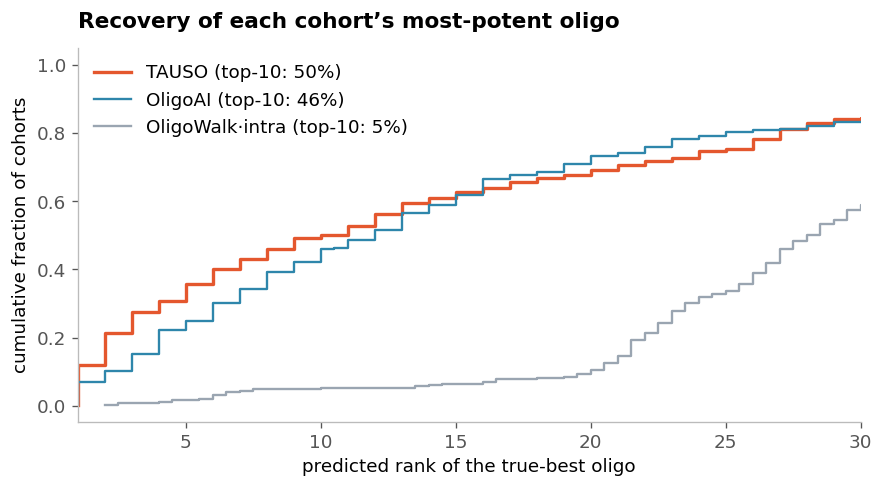

In [7]:
# recall: where does each cohort's truly-best oligo land in the predicted ranking?
fig, ax = plt.subplots(figsize=(7.5, 4.2))
for s in ['TAUSO','oligo_ai_score','OW_Intra_Oligo']:
    r = np.sort(v.best_rank_cdf(preds, s)); cdf = np.arange(1, len(r)+1)/len(r)
    ax.step(r, cdf, where='post', color=v.color(s), lw=2 if s=='TAUSO' else 1.4, label=f'{v.disp(s)} (top-10: {(r<=10).mean():.0%})')
ax.set_xlim(1, 30); ax.set_xlabel('predicted rank of the true-best oligo'); ax.set_ylabel('cumulative fraction of cohorts')
ax.set_title('Recovery of each cohort’s most-potent oligo'); ax.legend(frameon=False); plt.tight_layout(); plt.show()